# Clustering and Pattern discovery 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
# Load dataset
df = pd.read_csv("StudentsPerformance.csv")

# Select the 3 subject score columns
X = df[['math score', 'reading score', 'writing score']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Elbow Method ───────────────────────────────────────────────
inertias = []           # stores WCSS for each k
k_range  = range(1, 11) # test k from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)   # inertia = WCSS value

print("4c) Inertia values for each k:")
for k, inertia in zip(k_range, inertias):
    print(f"    k={k}  →  WCSS = {inertia:.2f}")

4c) Inertia values for each k:
    k=1  →  WCSS = 3000.00
    k=2  →  WCSS = 1253.86
    k=3  →  WCSS = 788.37
    k=4  →  WCSS = 604.92
    k=5  →  WCSS = 492.95
    k=6  →  WCSS = 432.72
    k=7  →  WCSS = 383.14
    k=8  →  WCSS = 340.83
    k=9  →  WCSS = 304.35
    k=10  →  WCSS = 274.20


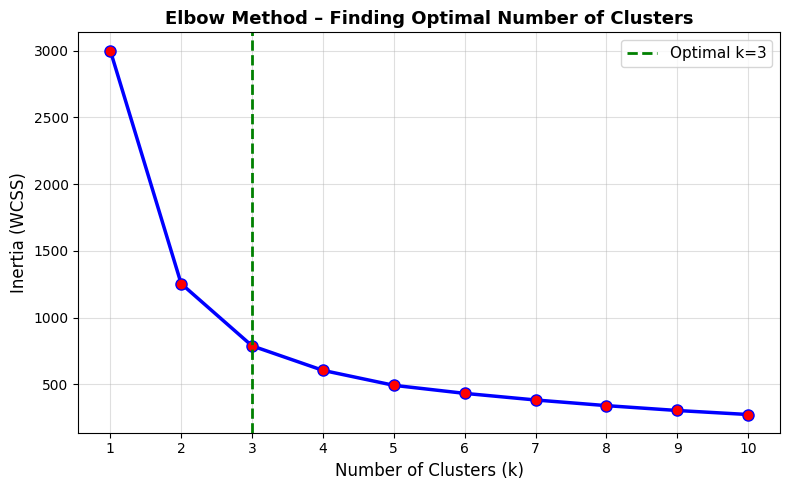

In [4]:
plt.figure(figsize=(8, 5))

plt.plot(list(k_range), inertias, 
         'bo-',           # blue circles connected by line
         linewidth=2.5, 
         markersize=8,
         markerfacecolor='red')

# Mark the elbow point (k=3 is usually optimal)
plt.axvline(x=3, color='green', linestyle='--', 
            linewidth=2, label='Optimal k=3')

plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method – Finding Optimal Number of Clusters', 
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.xticks(list(k_range))
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('task4_elbow.png', dpi=150)
plt.show()

In [5]:
# Use k=3 (from elbow method)
OPTIMAL_K = 3

kmeans = KMeans(
    n_clusters=OPTIMAL_K,   # number of clusters
    random_state=42,         # for reproducibility
    n_init=10                # run 10 times, pick best result
)

# Fit and assign cluster labels
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("4a) K-Means applied with k=3")
print(f"\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

# Show cluster centers (in original scale)
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
print(f"\nCluster Centers (original scale):")
print(f"{'Cluster':<12} {'Math':>8} {'Reading':>10} {'Writing':>10}")
print("-" * 44)
for i, center in enumerate(centers_original):
    print(f"Cluster {i}    {center[0]:>8.2f} {center[1]:>10.2f} {center[2]:>10.2f}")

4a) K-Means applied with k=3

Cluster Distribution:
Cluster
0    443
1    249
2    308
Name: count, dtype: int64

Cluster Centers (original scale):
Cluster          Math    Reading    Writing
--------------------------------------------
Cluster 0       65.34      68.46      67.82
Cluster 1       48.10      50.67      48.49
Cluster 2       81.71      85.15      84.21


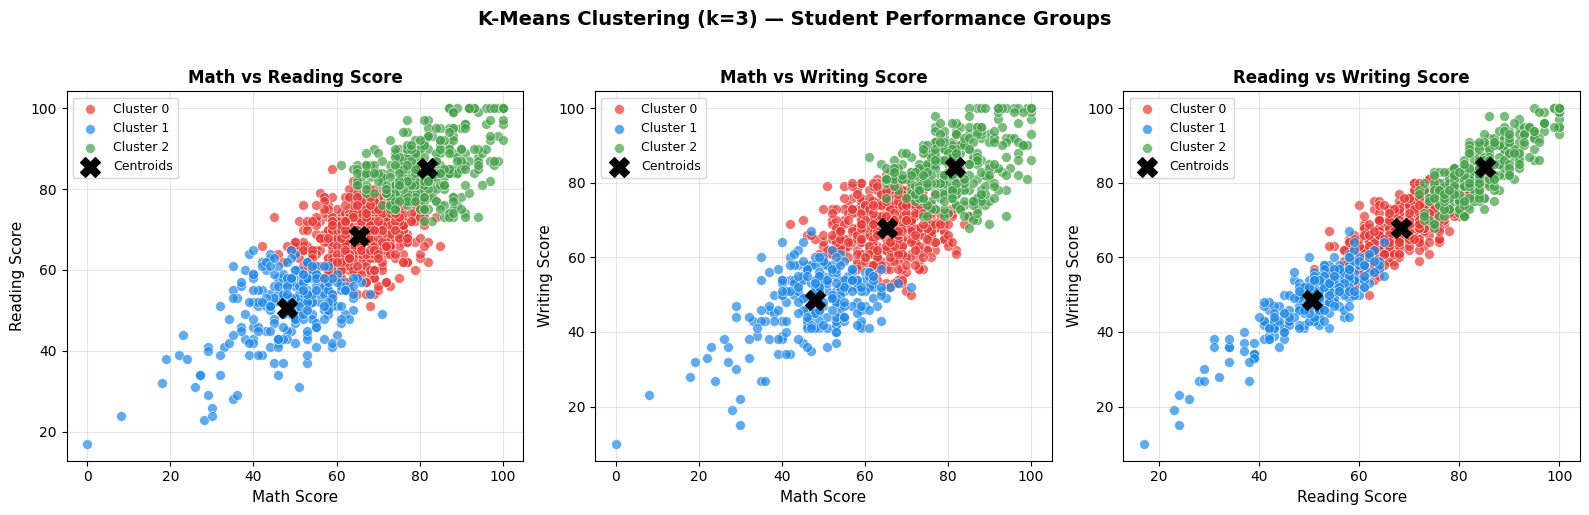

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#E53935', '#1E88E5', '#43A047']   # Red, Blue, Green
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

# ── Plot 1: Math vs Reading ────────────────────────────────────
for i in range(OPTIMAL_K):
    mask = df['Cluster'] == i
    axes[0].scatter(df.loc[mask, 'math score'],
                    df.loc[mask, 'reading score'],
                    c=colors[i], label=labels[i],
                    alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

# Plot centroids
axes[0].scatter(centers_original[:, 0], centers_original[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0].set_xlabel('Math Score', fontsize=11)
axes[0].set_ylabel('Reading Score', fontsize=11)
axes[0].set_title('Math vs Reading Score', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Math vs Writing ────────────────────────────────────
for i in range(OPTIMAL_K):
    mask = df['Cluster'] == i
    axes[1].scatter(df.loc[mask, 'math score'],
                    df.loc[mask, 'writing score'],
                    c=colors[i], label=labels[i],
                    alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

axes[1].scatter(centers_original[:, 0], centers_original[:, 2],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[1].set_xlabel('Math Score', fontsize=11)
axes[1].set_ylabel('Writing Score', fontsize=11)
axes[1].set_title('Math vs Writing Score', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# ── Plot 3: Reading vs Writing ─────────────────────────────────
for i in range(OPTIMAL_K):
    mask = df['Cluster'] == i
    axes[2].scatter(df.loc[mask, 'reading score'],
                    df.loc[mask, 'writing score'],
                    c=colors[i], label=labels[i],
                    alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

axes[2].scatter(centers_original[:, 1], centers_original[:, 2],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[2].set_xlabel('Reading Score', fontsize=11)
axes[2].set_ylabel('Writing Score', fontsize=11)
axes[2].set_title('Reading vs Writing Score', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('K-Means Clustering (k=3) — Student Performance Groups',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task4_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print("4d) Cluster Interpretation:")
print("=" * 55)

for i in range(OPTIMAL_K):
    cluster_df = df[df['Cluster'] == i]
    avg_math    = cluster_df['math score'].mean()
    avg_reading = cluster_df['reading score'].mean()
    avg_writing = cluster_df['writing score'].mean()
    overall_avg = (avg_math + avg_reading + avg_writing) / 3
    count       = len(cluster_df)

    print(f"\n  Cluster {i}  ({count} students)")
    print(f"  ─────────────────────────────────────")
    print(f"  Math    : {avg_math:.2f}")
    print(f"  Reading : {avg_reading:.2f}")
    print(f"  Writing : {avg_writing:.2f}")
    print(f"  Overall : {overall_avg:.2f}")

    # Auto-label based on overall average
    if overall_avg >= 75:
        print(f"  Label   : 🟢 HIGH Performers")
        print(f"  Insight : Excels in all subjects.")
        print(f"            Likely completed test prep and have strong")
        print(f"            parental education background.")
    elif overall_avg >= 55:
        print(f"  Label   : 🟡 AVERAGE Performers")
        print(f"  Insight : Moderate scores across all subjects.")
        print(f"            May benefit from targeted study support.")
    else:
        print(f"  Label   : 🔴 LOW Performers")
        print(f"  Insight : Struggling across all subjects.")
        print(f"            Requires academic intervention and support.")

4d) Cluster Interpretation:

  Cluster 0  (443 students)
  ─────────────────────────────────────
  Math    : 65.34
  Reading : 68.46
  Writing : 67.82
  Overall : 67.21
  Label   : 🟡 AVERAGE Performers
  Insight : Moderate scores across all subjects.
            May benefit from targeted study support.

  Cluster 1  (249 students)
  ─────────────────────────────────────
  Math    : 48.10
  Reading : 50.67
  Writing : 48.49
  Overall : 49.08
  Label   : 🔴 LOW Performers
  Insight : Struggling across all subjects.
            Requires academic intervention and support.

  Cluster 2  (308 students)
  ─────────────────────────────────────
  Math    : 81.71
  Reading : 85.15
  Writing : 84.21
  Overall : 83.69
  Label   : 🟢 HIGH Performers
  Insight : Excels in all subjects.
            Likely completed test prep and have strong
            parental education background.
